In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns



In [132]:
with open("Titanic-Dataset.csv") as f:
    titanicdf=pd.read_csv(f)

titanicdf

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [137]:
titanicdf.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


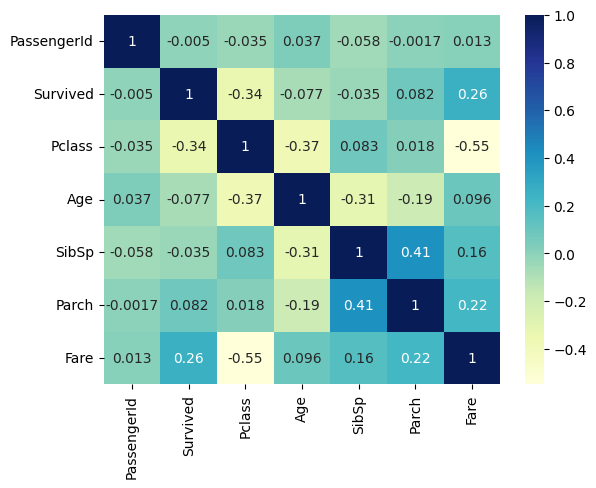

In [138]:
sns.heatmap(titanicdf.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.show()

In [140]:
titanicdf.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin'],
    inplace=True
)

In [141]:
titanicdf.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [142]:
titanicdf['Age'] = titanicdf['Age'].fillna(titanicdf['Age'].median())

In [143]:
titanicdf['Sex'] = titanicdf['Sex'].map({'male': 0, 'female': 1})

In [144]:
titanicdf = pd.get_dummies(titanicdf, columns=['Embarked'], drop_first=True)

In [145]:
titanicdf

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,False,True
887,1,1,1,19.0,0,0,30.0000,False,True
888,0,3,1,28.0,1,2,23.4500,False,True
889,1,1,0,26.0,0,0,30.0000,False,False


In [146]:
titanicdf['FamilySize'] = titanicdf['SibSp'] + titanicdf['Parch'] + 1
titanicdf.drop(columns=['SibSp', 'Parch'], inplace=True)

In [147]:
X = titanicdf.drop('Survived', axis=1)
y = titanicdf['Survived']

In [148]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [149]:
# combine features and target
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

# save to CSV
train_df.to_csv("titanic_train.csv", index=False)
test_df.to_csv("titanic_test.csv", index=False)

<Axes: >

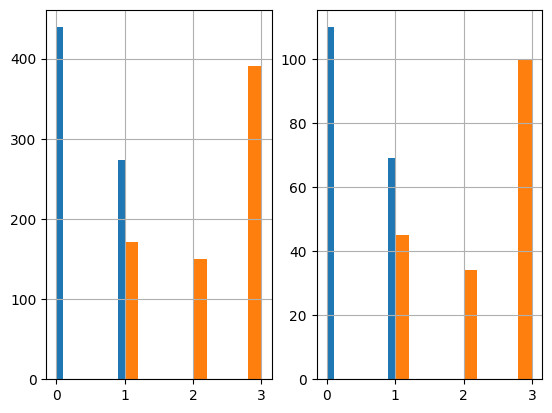

In [150]:
with open("titanic_test.csv") as f:
    titanic_test=pd.read_csv(f)

with open("titanic_train.csv") as f:
    titanic_train=pd.read_csv(f)

plt.subplot(1,2,1)
titanic_train['Survived'].hist()
titanic_train['Pclass'].hist()

plt.subplot(1,2,2)
titanic_test['Survived'].hist()
titanic_test['Pclass'].hist()

     Pclass  Sex   Age      Fare  Embarked_Q  Embarked_S  FamilySize
692       3    0  28.0   56.4958       False        True           1
481       2    0  28.0    0.0000       False        True           1
527       1    0  28.0  221.7792       False        True           1
855       3    1  18.0    9.3500       False        True           2
801       2    1  31.0   26.2500       False        True           3
..      ...  ...   ...       ...         ...         ...         ...
359       3    1  28.0    7.8792        True       False           1
258       1    1  35.0  512.3292       False       False           1
736       3    1  48.0   34.3750       False        True           5
462       1    0  47.0   38.5000       False        True           1
507       1    0  28.0   26.5500       False        True           1

[712 rows x 7 columns]


In [155]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
x_train_predict=model.predict(X_train)
print(x_train_predict)



[0 0 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0
 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1
 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 0 0
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 1 1 1 1 0 0 0 0
 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 1 1 0 1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0
 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0 0
 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0
 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 0 0
 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 

In [159]:
training_data_accuracy=accuracy_score(y_train,x_train_predict)
training_data_accuracy

0.8047752808988764

In [160]:
x_test_predict=model.predict(X_test)
print(x_test_predict)

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]


In [161]:
test_data_accuracy=accuracy_score(y_test,x_test_predict)
test_data_accuracy

0.7988826815642458

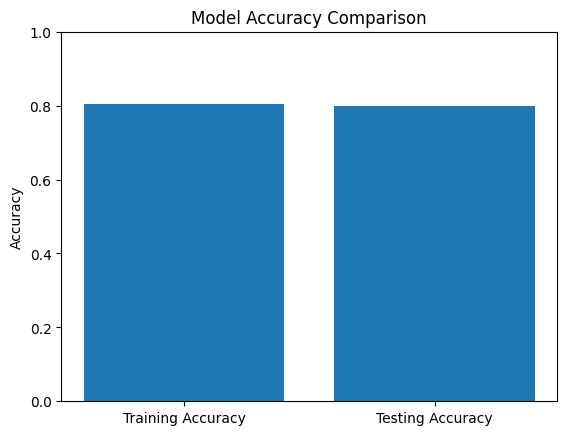

In [162]:

labels = ['Training Accuracy', 'Testing Accuracy']
values = [training_data_accuracy, test_data_accuracy]

plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

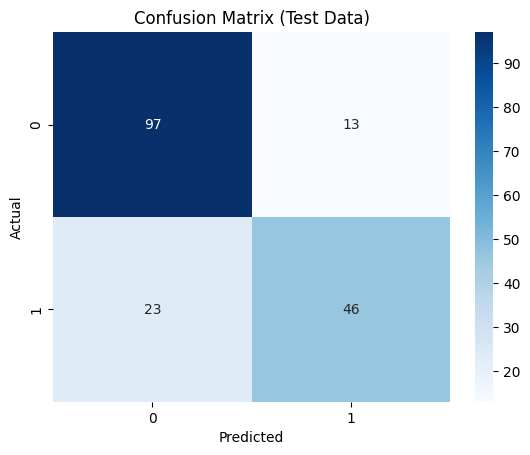

In [168]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, x_test_predict)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Data)")
plt.show()